In [26]:
# 导入测试得到的数据
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_path = "/Users/ccg/Study/Mujoco/IL/musculoco_GAIL/experiments/14_AMP_latent/runs/AMP_walk1/torques_and_ctrl.csv"

data = pd.read_csv(data_path)

# 取前100行数据进行分析
data = data.iloc[:1000]
data

,episode,step,time,hip_flexion_r,hip_adduction_r,hip_rotation_r,knee_angle_r,ankle_angle_r,hip_flexion_l,hip_adduction_l,...,action:per_long_l,action:per_tert_l,action:ext_dig_l,action:ext_hal_l,action:ercspn_r,action:ercspn_l,action:intobl_r,action:intobl_l,action:extobl_r,action:extobl_l
0,0.0,0.0,0.01,16.698334,-12.609027,-0.952364,-15.431073,-2.879114,45.251693,-16.513494,...,-1.856909,3.579678,3.401322,-2.025967,-1.601140,1.979078,-4.756398,3.137906,0.690416,6.155472
1,0.0,1.0,0.02,-19.527058,-29.820503,-6.408212,-22.467150,-2.618934,61.034649,-21.691869,...,-3.354090,4.808406,5.241076,-2.121882,0.884685,-6.172332,-0.424788,-2.104522,0.641759,6.333369
2,0.0,2.0,0.03,-22.392852,-27.373959,4.839005,-33.245735,-2.215598,68.529203,-13.095324,...,-3.978588,4.241514,6.567344,-1.325204,2.037042,-7.653050,0.655333,-0.949359,2.300190,5.261144
3,0.0,3.0,0.04,-20.065597,-21.667207,3.881440,-37.359028,-3.046537,70.766536,-12.793800,...,-2.882812,3.796317,5.099856,-2.330961,0.411983,-3.862259,0.271472,0.006977,3.512526,4.774399
4,0.0,4.0,0.05,-17.731890,-14.483998,2.321409,-37.709299,-3.250653,70.854965,-18.849711,...,-1.759351,4.256035,4.238605,-3.116123,-0.154064,-2.127829,0.545041,-0.938339,2.724958,4.507743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,995.0,9.96,97.232511,-35.852658,-0.631682,48.874158,-72.199893,-54.747835,14.279695,...,0.548330,3.339237,-0.713066,-1.688756,1.026661,-0.398457,-5.683862,1.122504,0.617951,3.263329
996,0.0,996.0,9.97,79.252397,-33.197837,-0.995585,34.161966,-88.326323,-62.407391,6.057835,...,0.706080,2.983175,-0.744331,-1.410866,1.261186,0.597421,-5.860534,1.482900,0.537891,2.605856
997,0.0,997.0,9.98,63.624965,-29.705907,-1.443126,18.794375,-99.201329,-60.946575,1.798219,...,0.887399,2.388420,-0.568018,-1.334729,1.191307,0.514835,-6.234106,1.138264,0.682398,2.507612
998,0.0,998.0,9.99,60.175255,-29.855172,-2.221374,13.307728,-104.316795,-53.674873,0.718716,...,1.297217,2.312248,-0.804142,-1.584854,1.087101,0.350515,-6.188746,0.977651,1.331117,2.850177


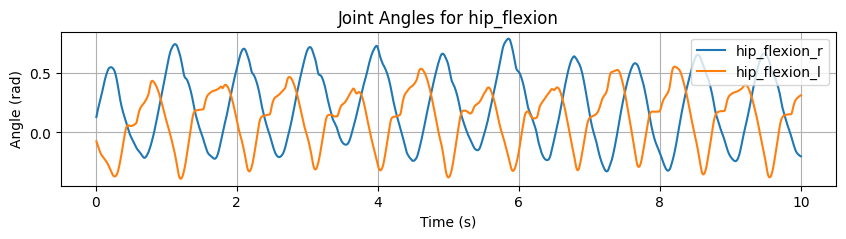

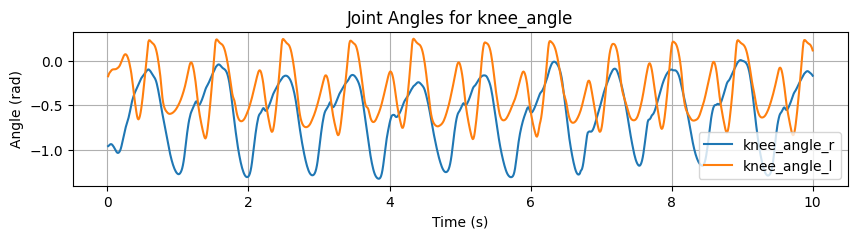

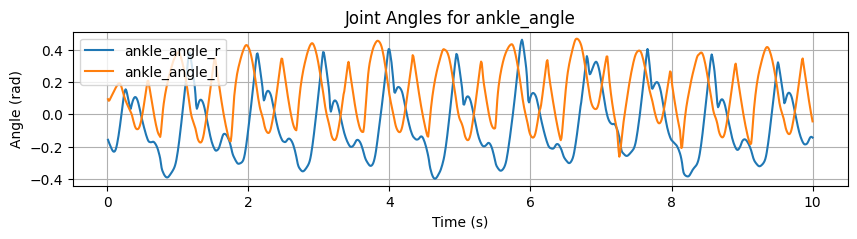

In [27]:
# 画出各个关节的角度曲线,在 CSV 中以 q:joint_name命名。左右腿的同一个关节的角度画在同一张图上
joint_names = ['hip_flexion_r', 'knee_angle_r', 'ankle_angle_r', 'hip_flexion_l', 'knee_angle_l', 'ankle_angle_l']
for joint_name in ['hip_flexion', 'knee_angle', 'ankle_angle']:
    plt.figure(figsize=(10,2))
    plt.plot(data['time'], data[f'q:{joint_name}_r'], label=f'{joint_name}_r')
    plt.plot(data['time'], data[f'q:{joint_name}_l'], label=f'{joint_name}_l')
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (rad)')
    plt.title(f'Joint Angles for {joint_name}')
    plt.legend()
    plt.grid()
    plt.show()

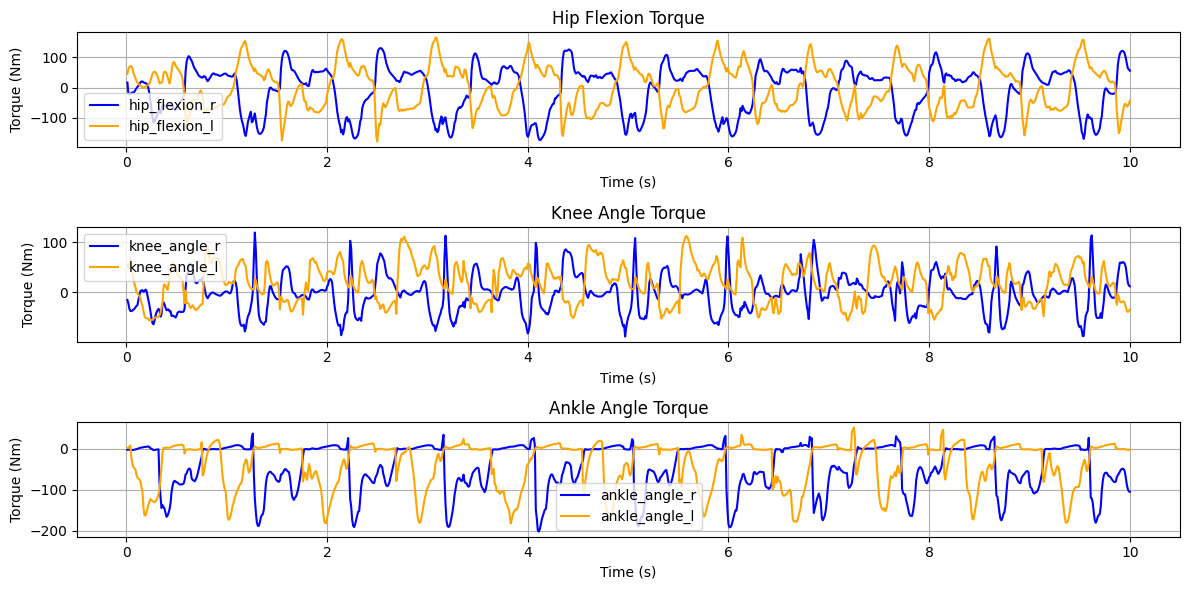

In [28]:
# 先画出各个关节的力矩曲线，左右画在同一张图上
# “hip_flexion_r” and “hip_flexion_l” on the same plot
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(data['time'], data['hip_flexion_r'], label='hip_flexion_r', color='blue')
plt.plot(data['time'], data['hip_flexion_l'], label='hip_flexion_l', color='orange')
plt.title('Hip Flexion Torque')
plt.xlabel('Time (s)')
plt.ylabel('Torque (Nm)')
plt.legend()
# 加上网格线
plt.grid()

# “knee_angle_r” and “knee_angle_l” on the same plot
plt.subplot(3, 1, 2)
plt.plot(data['time'], data['knee_angle_r'], label='knee_angle_r', color='blue')
plt.plot(data['time'], data['knee_angle_l'], label='knee_angle_l', color='orange')
plt.title('Knee Angle Torque')
plt.xlabel('Time (s)')
plt.ylabel('Torque (Nm)')
plt.legend()
plt.grid()

# “ankle_angle_r” and “ankle_angle_l” on the same plot
plt.subplot(3, 1, 3)
plt.plot(data['time'], data['ankle_angle_r'], label='ankle_angle_r', color='blue')
plt.plot(data['time'], data['ankle_angle_l'], label='ankle_angle_l', color='orange')
plt.title('Ankle Angle Torque')
plt.xlabel('Time (s)')
plt.ylabel('Torque (Nm)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [23]:
# 打印出所有控制信号的名字
# print("Control Signal Names:")
# for col in data.columns:
#     if 'ctrl' in col:
#         print(col)
# for col in data.columns:
#     if 'act' in col:
#         print(col)
# Control Signal Names:
# ctrl:glut_med1_r
# ctrl:glut_med2_r
# ctrl:glut_med3_r
# ctrl:glut_min1_r
# ctrl:glut_min2_r
# ctrl:glut_min3_r
# ctrl:semimem_r
# ctrl:semiten_r
# ctrl:bifemlh_r
# ctrl:bifemsh_r
# ctrl:sar_r
# ctrl:add_long_r
# ctrl:add_brev_r
# ctrl:add_mag1_r
# ctrl:add_mag2_r
# ctrl:add_mag3_r
# ctrl:tfl_r
# ctrl:pect_r
# ctrl:grac_r
# ctrl:glut_max1_r
# ctrl:glut_max2_r
# ctrl:glut_max3_r
# ctrl:iliacus_r
# ctrl:psoas_r
# ctrl:quad_fem_r
# ctrl:gem_r
# ctrl:peri_r
# ctrl:rect_fem_r
# ctrl:vas_med_r
# ctrl:vas_int_r
# ctrl:vas_lat_r
# ctrl:med_gas_r
# ctrl:lat_gas_r
# ctrl:soleus_r
# ctrl:tib_post_r
# ctrl:flex_dig_r
# ctrl:flex_hal_r
# ctrl:tib_ant_r
# ctrl:per_brev_r
# ctrl:per_long_r
# ctrl:per_tert_r
# ctrl:ext_dig_r
# ctrl:ext_hal_r
# ctrl:glut_med1_l
# ctrl:glut_med2_l
# ctrl:glut_med3_l
# ctrl:glut_min1_l
# ctrl:glut_min2_l
# ctrl:glut_min3_l
# ctrl:semimem_l
# ctrl:semiten_l
# ctrl:bifemlh_l
# ctrl:bifemsh_l
# ctrl:sar_l
# ctrl:add_long_l
# ctrl:add_brev_l
# ctrl:add_mag1_l
# ctrl:add_mag2_l
# ctrl:add_mag3_l
# ctrl:tfl_l
# ctrl:pect_l
# ctrl:grac_l
# ctrl:glut_max1_l
# ctrl:glut_max2_l
# ctrl:glut_max3_l
# ctrl:iliacus_l
# ctrl:psoas_l
# ctrl:quad_fem_l
# ctrl:gem_l
# ctrl:peri_l
# ctrl:rect_fem_l
# ctrl:vas_med_l
# ctrl:vas_int_l
# ctrl:vas_lat_l
# ctrl:med_gas_l
# ctrl:lat_gas_l
# ctrl:soleus_l
# ctrl:tib_post_l
# ctrl:flex_dig_l
# ctrl:flex_hal_l
# ctrl:tib_ant_l
# ctrl:per_brev_l
# ctrl:per_long_l
# ctrl:per_tert_l
# ctrl:ext_dig_l
# ctrl:ext_hal_l
# ctrl:ercspn_r
# ctrl:ercspn_l
# ctrl:intobl_r
# ctrl:intobl_l
# ctrl:extobl_r
# ctrl:extobl_l


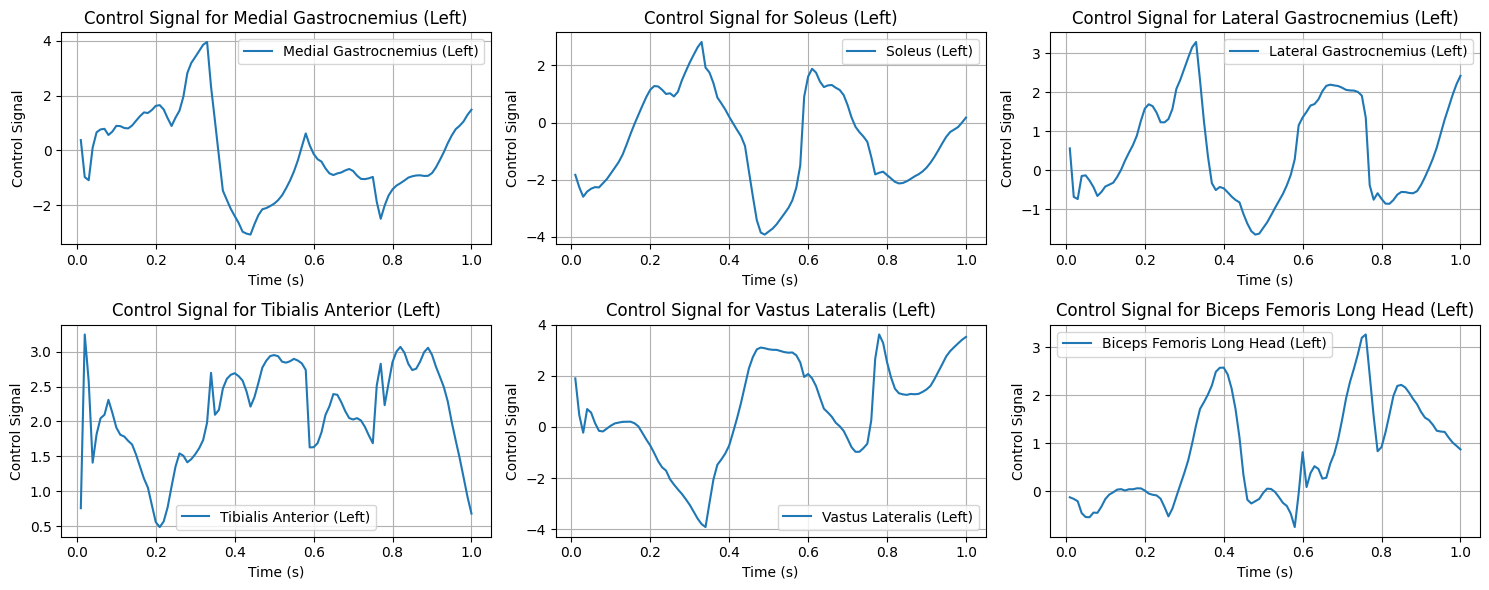

In [24]:
# 画出右腿最主要肌肉控制信号的变化曲线，
major_muscles = [
    'ctrl:med_gas_l', # 腓肠肌内侧头
    'ctrl:soleus_l', # 左腿比目鱼肌
    'ctrl:lat_gas_l', # 腓肠肌外侧头
    'ctrl:tib_ant_l', # 左腿胫前肌
    'ctrl:vas_lat_l', # 左腿外侧股四头肌
    'ctrl:bifemlh_l'  # 
]
muscle_labels = {
    'ctrl:med_gas_l': 'Medial Gastrocnemius (Left)',
    'ctrl:lat_gas_l': 'Lateral Gastrocnemius (Left)',
    'ctrl:soleus_l': 'Soleus (Left)',
    'ctrl:tib_ant_l': 'Tibialis Anterior (Left)',
    'ctrl:vas_lat_l': 'Vastus Lateralis (Left)',
    'ctrl:bifemlh_l': 'Biceps Femoris Long Head (Left)'
}
# 画图
plt.figure(figsize=(15, 6))
for muscle in major_muscles:
    plt.subplot(2, 3, major_muscles.index(muscle) + 1)
    plt.plot(data['time'], data[muscle], label=muscle_labels[muscle])
    plt.title(f'Control Signal for {muscle_labels[muscle]}')
    plt.xlabel('Time (s)')
    plt.ylabel('Control Signal')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()

KeyError: 'act:med_gas_l'

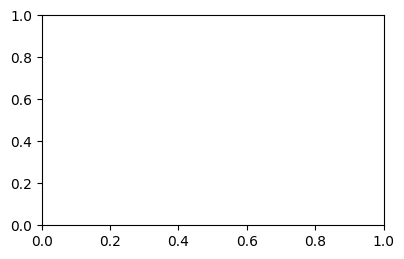

In [25]:
# 画出右腿最主要肌肉控制信号的变化曲线，
major_muscles = [
    'act:med_gas_l', # 腓肠肌内侧头
    'act:soleus_l', # 左腿比目鱼肌
    'act:lat_gas_l', # 腓肠肌外侧头
    'act:tib_ant_l', # 左腿胫前肌
    'act:vas_lat_l', # 左腿外侧股四头肌
    'act:bifemsh_r'  # 左侧腿股二头肌短头
]
muscle_labels = {
    'act:med_gas_l': 'Medial Gastrocnemius (Left)',
    'act:lat_gas_l': 'Lateral Gastrocnemius (Left)',
    'act:soleus_l': 'Soleus (Left)',
    'act:tib_ant_l': 'Tibialis Anterior (Left)',
    'act:vas_lat_l': 'Vastus Lateralis (Left)',
    'act:bifemsh_r': 'Biceps Femoris Short Head (Right)'
}
# 画图
plt.figure(figsize=(15, 6))
for muscle in major_muscles:
    plt.subplot(2, 3, major_muscles.index(muscle) + 1)
    plt.plot(data['time'], data[muscle], label=muscle_labels[muscle])
    plt.title(f'Activation for {muscle_labels[muscle]}')
    plt.xlabel('Time (s)')
    plt.ylabel('Control Signal')
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()

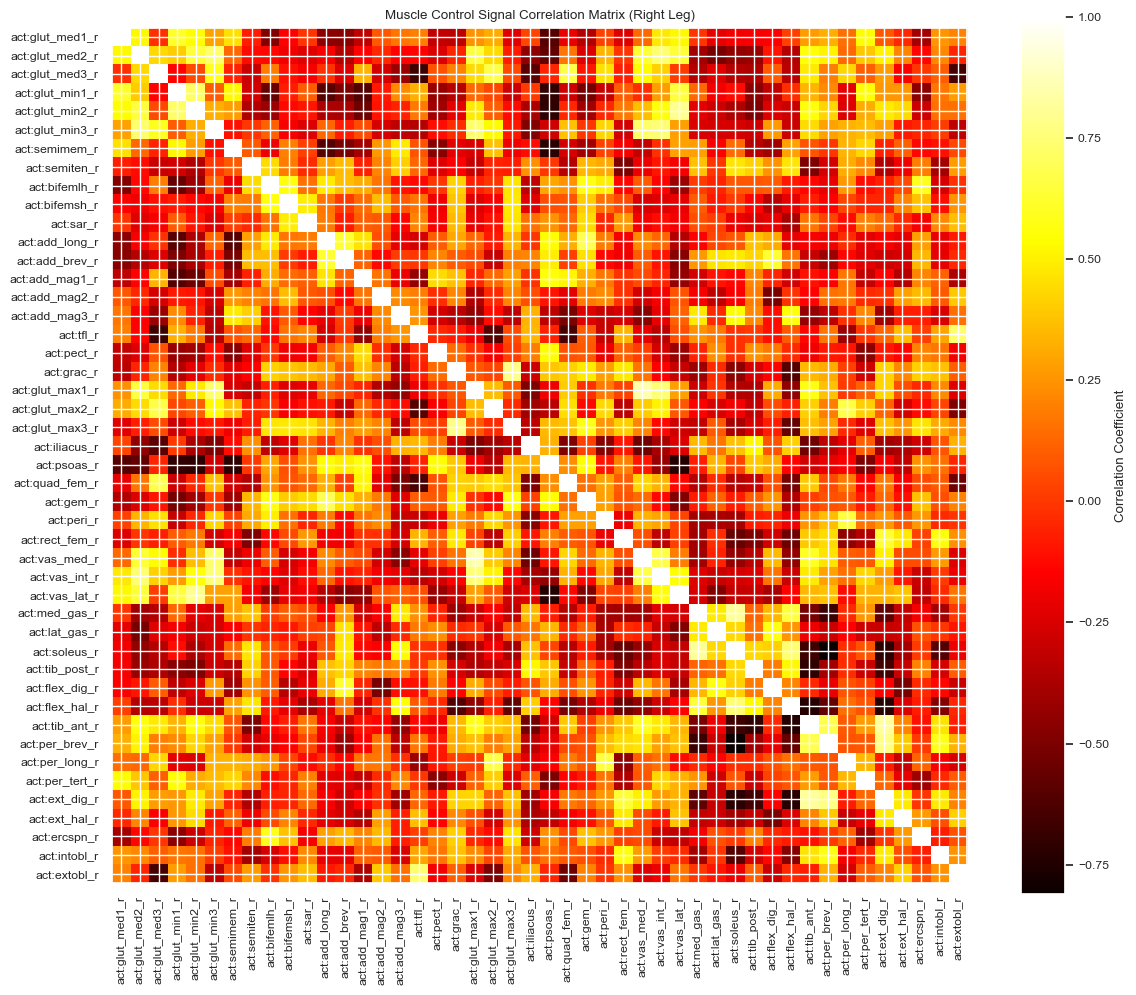

In [78]:
# 分析肌肉的共激活情况，以右腿为例
from itertools import combinations
muscle_act = [col for col in data.columns if col.startswith('act:') and col.endswith('_r')]
correlation_matrix = pd.DataFrame(index=muscle_act, columns=muscle_act)
for muscle1, muscle2 in combinations(muscle_act, 2):
    correlation = data[muscle1].corr(data[muscle2])
    correlation_matrix.loc[muscle1, muscle2] = correlation
    correlation_matrix.loc[muscle2, muscle1] = correlation
# 填充对角线为1
for muscle in muscle_act:
    correlation_matrix.loc[muscle, muscle] = 1.0
correlation_matrix = correlation_matrix.astype(float)
# 画出热力图
plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, cmap='hot', interpolation='nearest')
plt.colorbar(label='Correlation Coefficient')
plt.xticks(ticks=np.arange(len(muscle_act)), labels=muscle_act, rotation=90)
plt.yticks(ticks=np.arange(len(muscle_act)), labels=muscle_act)
plt.title('Muscle Control Signal Correlation Matrix (Right Leg)')
plt.tight_layout()
plt.show()  

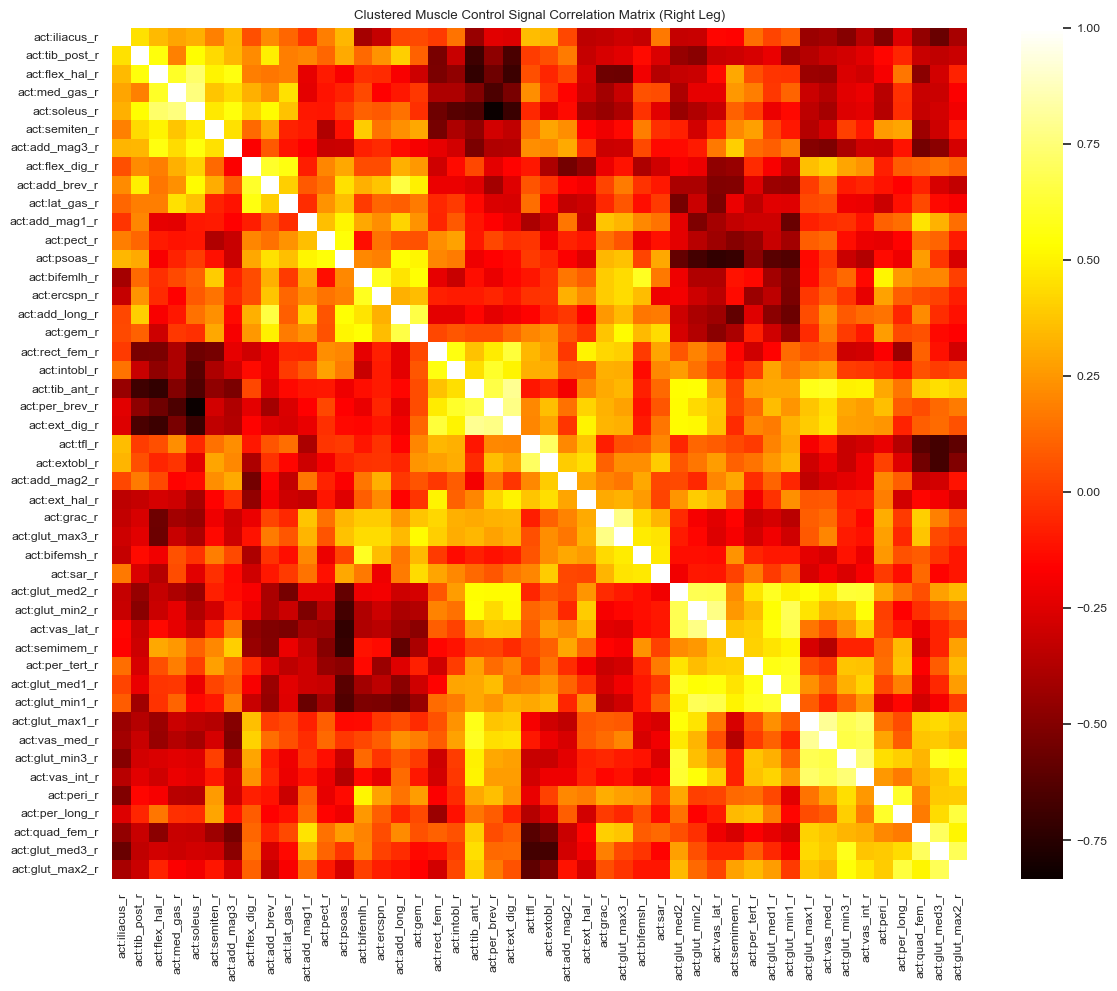

In [71]:
# 先把肌肉聚类后再绘制热力图
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
# 层次聚类
Z = linkage(correlation_matrix, method='ward')
# 获取聚类后的顺序
dendro = dendrogram(Z, no_plot=True)
ordered_indices = leaves_list(Z)
ordered_muscles = [muscle_act[i] for i in ordered_indices]
# 重排相关矩阵
ordered_correlation_matrix = correlation_matrix.loc[ordered_muscles, ordered_muscles]
# 画出热力图
plt.figure(figsize=(12, 10))
# 使用seaborn绘制更美观的热力图，颜色分层更显著,不使用hot或viridis，使用颜色尽可能多的热力图形式

sns.set(font_scale=0.8)
sns.heatmap(ordered_correlation_matrix, cmap='hot', annot=False)
plt.title('Clustered Muscle Control Signal Correlation Matrix (Right Leg)')
plt.tight_layout()
plt.show()


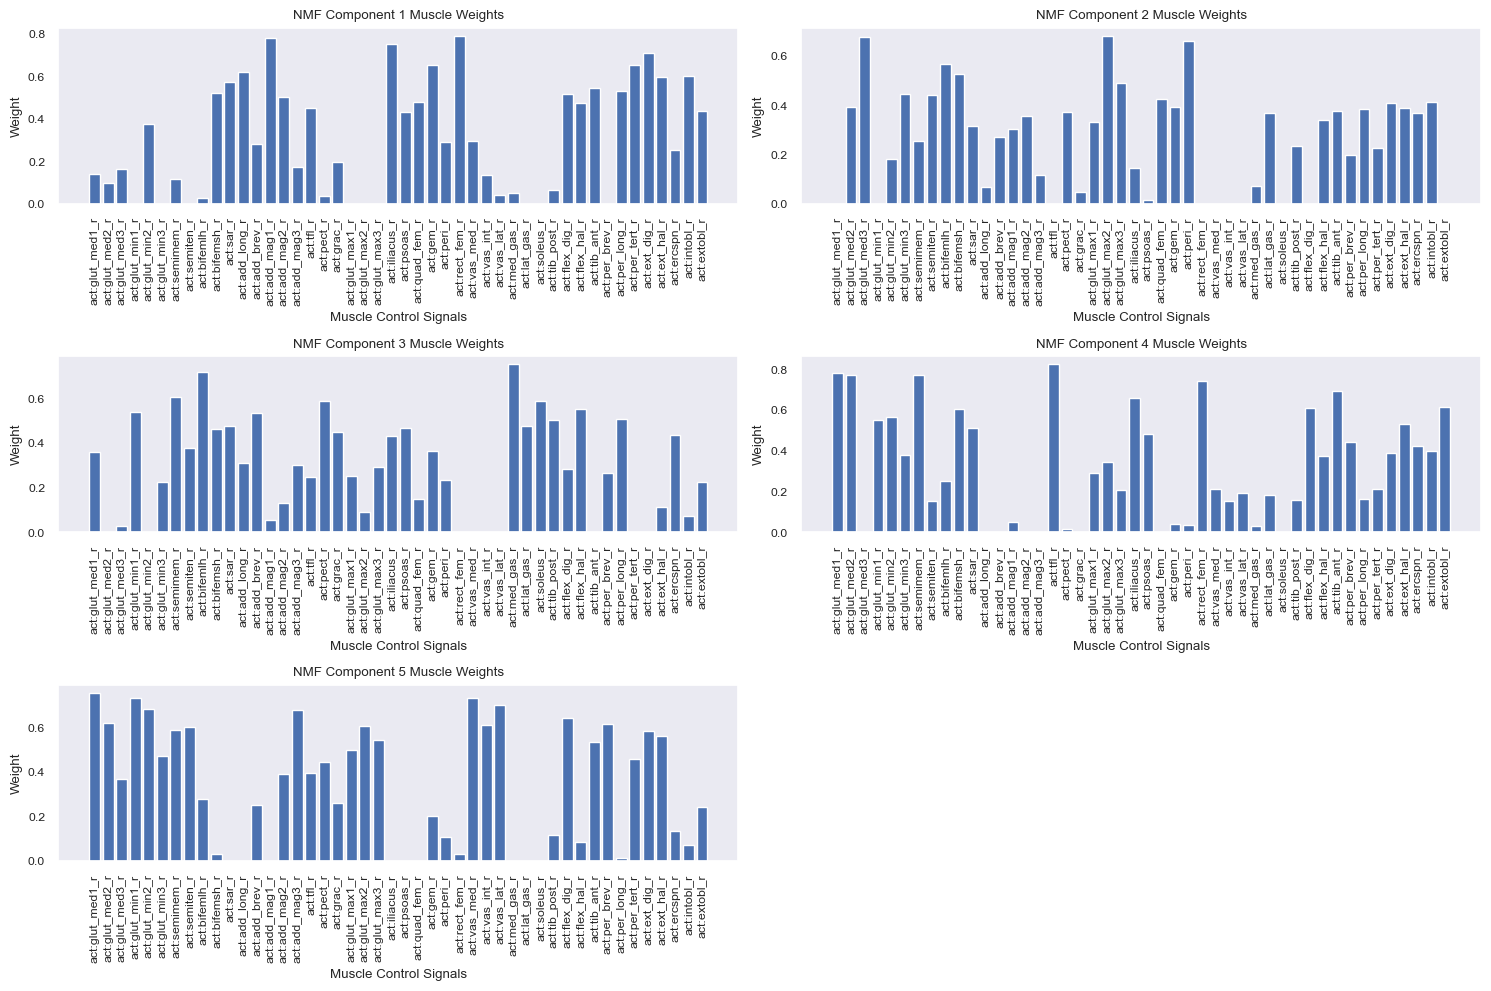

In [10]:
# 使用NMF进行肌肉控制信号的降维分析
from sklearn.decomposition import NMF
# 提取右腿肌肉控制信号数据
right_leg_data = data[muscle_act].values
# 使用NMF进行降维，设定成分数为5
nmf_model = NMF(n_components=5, init='random', random_state=0)
W = nmf_model.fit_transform(right_leg_data)
H = nmf_model.components_
# 画出每个成分的肌肉权重
plt.figure(figsize=(15, 10))
for i in range(H.shape[0]):
    plt.subplot(3, 2, i + 1)
    plt.bar(muscle_act, H[i])
    plt.title(f'NMF Component {i + 1} Muscle Weights')
    plt.xlabel('Muscle Control Signals')
    plt.ylabel('Weight')
    plt.xticks(rotation=90)
    plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
# 自动诊断：步态对称性、相位与步频
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

# 如果前面没加载 data，这里兜底
if 'data' not in globals():
    data = pd.read_csv(data_path)

df = data.copy().iloc[:1000]
t = df['time'].to_numpy()
dt = float(np.median(np.diff(t)))


def lag_corr(a, b, dt_s):
    a = (a - a.mean()) / (a.std() + 1e-8)
    b = (b - b.mean()) / (b.std() + 1e-8)
    xc = np.correlate(a, b, mode='full')
    lags = np.arange(-len(a) + 1, len(a))
    k = lags[np.argmax(xc)]
    return float(np.corrcoef(a, b)[0, 1]), float(k * dt_s)

rows = []
for j in ['hip_flexion', 'knee_angle', 'ankle_angle']:
    r = df[f'q:{j}_r'].to_numpy()
    l = df[f'q:{j}_l'].to_numpy()
    corr, lag_s = lag_corr(r, l, dt)
    rom_r = float(r.max() - r.min())
    rom_l = float(l.max() - l.min())
    rows.append({
        'joint': j,
        'corr_r_l': corr,
        'lag_s': lag_s,
        'rom_r': rom_r,
        'rom_l': rom_l,
        'rom_diff': abs(rom_r - rom_l),
    })

report = pd.DataFrame(rows)

# 步频估计（右髋屈曲峰值间隔）
hip_r = df['q:hip_flexion_r'].to_numpy()
peaks, _ = find_peaks(hip_r, distance=max(1, int(0.35 / dt)))
step_freq_hz = float(1.0 / np.diff(t[peaks]).mean()) if len(peaks) > 1 else np.nan

print(f'duration={t[-1]-t[0]:.2f}s, step_freq={step_freq_hz:.3f} Hz, peaks={len(peaks)}')
print('')
print('关节对称性报告:')
display(report)

# 简单规则化提示
print('')
print('诊断提示:')
for _, row in report.iterrows():
    msg = []
    if row['rom_diff'] > 0.12:
        msg.append('左右活动幅度差偏大')
    if abs(row['lag_s']) < 0.08 and row['joint'] != 'knee_angle':
        msg.append('左右相位差偏小（可能趋向同相）')
    if row['joint'] == 'knee_angle' and row['corr_r_l'] > 0.3:
        msg.append('膝关节左右同相偏强')
    if not msg:
        msg.append('该关节指标基本正常')
    print(f"- {row['joint']}: " + '；'.join(msg))